In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"

df = pd.read_csv(url)

display(df.head())
display(df.info())

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    object 
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), object(1)
memory usage: 7.6+ KB


None

In [2]:
df.groupby('Species').count()

,Weight,Length,Diagonal,Height,Width
Species,,,,,
Bream,35,35,35,35,35
Parkki,11,11,11,11,11
Perch,56,56,56,56,56
Pike,17,17,17,17,17
Roach,20,20,20,20,20
Smelt,14,14,14,14,14
Whitefish,6,6,6,6,6


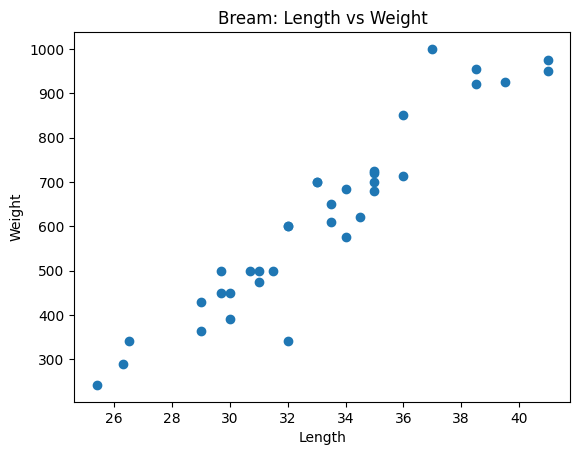

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
fish = pd.read_csv(
    "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"
)

# Bream(브림:도미)만 선택
bream = fish[fish["Species"] == "Bream"]

# 산점도 그리기
plt.scatter(bream["Length"], bream["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Bream: Length vs Weight")
plt.show()


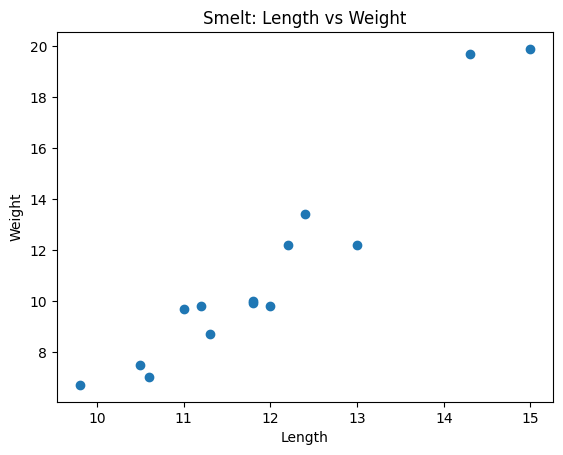

In [4]:
# Smelt(스멜트:빙어)만 선택
smelt = fish[fish["Species"] == "Smelt"]

# 산점도
plt.scatter(smelt["Length"], smelt["Weight"])

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Smelt: Length vs Weight")

plt.show()

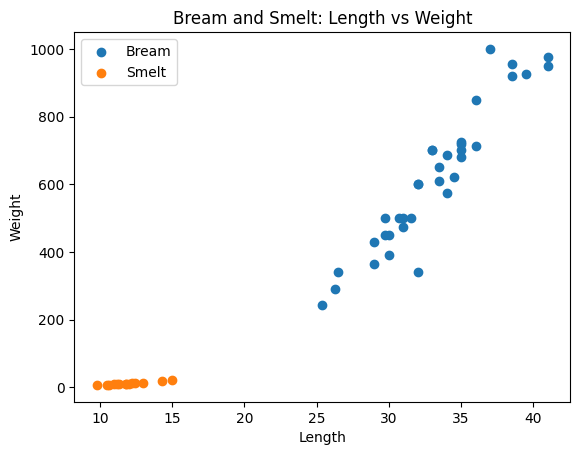

In [5]:
# 산점도 그리기
plt.scatter(bream["Length"], bream["Weight"], label="Bream")
plt.scatter(smelt["Length"], smelt["Weight"], label="Smelt")

# 그래프 설정
plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Bream and Smelt: Length vs Weight")
plt.legend()

plt.show()
# Bream과 Smelt 모두 길이가 길어질수록 무게가 증가하는 양의 관계를 보이지만,
# Bream이 Smelt보다 전반적으로 크고 무거우며 두 종의 데이터가 비교적 뚜렷하게 구분된다.

In [6]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier


# 2. Bream과 Smelt만 선택
fish = fish[fish["Species"].isin(["Bream", "Smelt"])]
fish.head()


,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340


In [7]:
# 3. 입력 데이터(X)
#    Length와 Weight를 사용
X = fish[["Length", "Weight"]]

# 4. 타깃 데이터(y)
#    Bream = 1, Smelt = 0
y = fish["Species"].map({"Bream": 1, "Smelt": 0})
print(X)
print(y)


     Length  Weight
0      25.4   242.0
1      26.3   290.0
2      26.5   340.0
3      29.0   363.0
4      29.0   430.0
5      29.7   450.0
6      29.7   500.0
7      30.0   390.0
8      30.0   450.0
9      30.7   500.0
10     31.0   475.0
11     31.0   500.0
12     31.5   500.0
13     32.0   340.0
14     32.0   600.0
15     32.0   600.0
16     33.0   700.0
17     33.0   700.0
18     33.5   610.0
19     33.5   650.0
20     34.0   575.0
21     34.0   685.0
22     34.5   620.0
23     35.0   680.0
24     35.0   700.0
25     35.0   725.0
26     35.0   720.0
27     36.0   714.0
28     36.0   850.0
29     37.0  1000.0
30     38.5   920.0
31     38.5   955.0
32     39.5   925.0
33     41.0   975.0
34     41.0   950.0
145     9.8     6.7
146    10.5     7.5
147    10.6     7.0
148    11.0     9.7
149    11.2     9.8
150    11.3     8.7
151    11.8    10.0
152    11.8     9.9
153    12.0     9.8
154    12.2    12.2
155    12.4    13.4
156    13.0    12.2
157    14.3    19.7
158    15.0    19.9


In [8]:
# 5. KNN(k-최근접 이웃 알고리즘) 모델 생성,
kn = KNeighborsClassifier(n_neighbors=5) # n_neighbors=5 가장 가까운 데이터 5개를 사용 : 동점이 안나오게 홀수를 사용

# 6. 모델 학습
kn.fit(X, y)

# 6-2. 모델 평가 : 정확도 = 맞힌 개수 / 전체 데이터 개수
# 모델이 얼마나 정확하게 예측했는지 확인
# (훈련 데이터와 테스트 데이터를 동일한 데이터를 사용하는 것은 좋지않음. 보통은 데이터를 훈련 데이터와 테스트 데이터로 나눠서 확인)
print(kn.score(X, y)) # 1.0이면 100% 정확성

# 7. 새로운 물고기 예측

new_fish = [[30, 500]] # Bream
# new_fish = [[10, 7]] # Smelt

prediction = kn.predict(new_fish)
# 새로운 물고기 Length=30, Weight=500을 넣으면
# 기존 데이터와의 거리를 계산
# 가까운 데이터 K(n_neighbors=5)개 선택
# 가장 많은 클래스를 선택
# 결과 반환

print('예측값:', prediction, ("Bream" if prediction[0] == 1 else "Smelt"))

1.0
예측값: [1] Bream


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


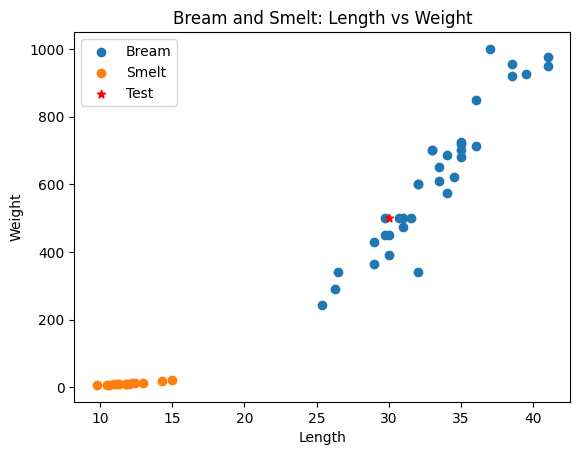

In [9]:
import matplotlib.pyplot as plt

# 테스트할 물고기
test_length = 30
test_weight = 500

# 산점도 그리기
plt.scatter(bream["Length"], bream["Weight"], label="Bream")
plt.scatter(smelt["Length"], smelt["Weight"], label="Smelt")

# 테스트 좌표를 빨간색으로 표시
plt.scatter(
    test_length,
    test_weight,
    color="red",
    marker="*", # 별모양으로 표시
    label="Test"
)

# 그래프 설정
plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Bream and Smelt: Length vs Weight")
plt.legend()

plt.show()


In [11]:
# n_neighbors를 5부터 49까지 하나씩 바꿔가면서 정확도(score)를 확인
# 실제로 어떤 n_neighbors가 새로운 데이터를 잘 분류하는지 확인하려면 train/test를 나눈 뒤
# X_train	훈련용 입력 데이터
# y_train	훈련용 정답 데이터
# X_test	테스트용 입력 데이터
# y_test	테스트용 정답 데이터
# 으로 정확도를 비교하는 것이 더 적절합니다. X = 입력 데이터(특성), y = 정답(타깃)으로 표현하는 관례

for n in range(5, 50):
    kn = KNeighborsClassifier(n_neighbors=n)
    kn.fit(X, y)

    score = kn.score(X, y)

    print(f"n_neighbors={n}, 정확도={score:.2f}")



n_neighbors=5, 정확도=1.00
n_neighbors=6, 정확도=1.00
n_neighbors=7, 정확도=1.00
n_neighbors=8, 정확도=1.00
n_neighbors=9, 정확도=1.00
n_neighbors=10, 정확도=1.00
n_neighbors=11, 정확도=1.00
n_neighbors=12, 정확도=1.00
n_neighbors=13, 정확도=1.00
n_neighbors=14, 정확도=1.00
n_neighbors=15, 정확도=1.00
n_neighbors=16, 정확도=1.00
n_neighbors=17, 정확도=1.00
n_neighbors=18, 정확도=0.98
n_neighbors=19, 정확도=0.98
n_neighbors=20, 정확도=0.98
n_neighbors=21, 정확도=0.98
n_neighbors=22, 정확도=0.98
n_neighbors=23, 정확도=0.98
n_neighbors=24, 정확도=0.98
n_neighbors=25, 정확도=0.98
n_neighbors=26, 정확도=0.98
n_neighbors=27, 정확도=0.98
n_neighbors=28, 정확도=0.96
n_neighbors=29, 정확도=0.71
n_neighbors=30, 정확도=0.71
n_neighbors=31, 정확도=0.71
n_neighbors=32, 정확도=0.71
n_neighbors=33, 정확도=0.71
n_neighbors=34, 정확도=0.71
n_neighbors=35, 정확도=0.71
n_neighbors=36, 정확도=0.71
n_neighbors=37, 정확도=0.71
n_neighbors=38, 정확도=0.71
n_neighbors=39, 정확도=0.71
n_neighbors=40, 정확도=0.71
n_neighbors=41, 정확도=0.71
n_neighbors=42, 정확도=0.71
n_neighbors=43, 정확도=0.71
n_neighbors=44, 정확도=0.71
n_nei